# Variational Autoencoders (VAEs) (2-24-26)

## Introduction
* An autoencoder learns how to compress data (the encoder) and then reconstruct it (the decoder)
* A variational autoencoders learns how to compress the data and then to generate new data. Do accomplish this we need to consider the latent space, the representation of the data after the encoder but before the decoder.

## Why Are Autoencoders Not Generative?
* A standard autoencoders learns $x \longrightarrow z \longrightarrow \hat{x}$ by minimizing the reconstruction error $||x-\hat{x}||^2$
    * It is a deterministic model.
* The encoder creates the map $x\longrightarrow z$ but nothing forces the latent space to follow a known distribution, be smooth, be continuous, or be connected.
* Generating new data requires sampling directly from the latent space (without using the encoder) and then sending the sample through the decoder.
    * Since there is no structure to the latent space this will result in sparse clusters, empty regions, and no global structure.

## Variational Autoencoders
* A VAE makes the following assumptions:
    * Data is generated from a distribution: $p_\theta(x|z)$
    * Latent variables follow a prior $p(z) = N(\mu,\sigma)$
        * A prior is essentially an assumption you are making about the shape or the distribution of the data.
* The VAE learns the full process, both the distribution that represents the latent space and how the input iteracts with the latent space.


## Variational Inference
* Instead of mapping x directly to z the algorithm instead performs the following mapping: $x \longrightarrow (\mu(x), \sigma(x))$
* This means that the latent spaces draws from a distribution with mean $\mu$ and variance $\sigma$. 
* **The output of the encoder is a mean and a variance, not just a single point**

## Evidence Lower Bound (ELBO)
* More computationally efficient loss function made of two terms:
    * Reconstruction loss which ensures the decoded data resembles the input
    * KL (Kullback-Leibler) divergence term which forces the VAE to learn towards a latent space represented by a distribution with mean of 0 and variance of 1.
    * The KL term makes the latent space smooth and allows nearby points to decode to similar outputs.

## Reparameterization Trick
* Sampling z directly from a distribution breaks the backpropagation, so instead the latent space representation is represented as:
    * $z = \mu + \sigma\epsilon$ where $\epsilon$ is drawn from the normal distribution.


## VAEs vs. Diffusion Models for Image Generation
* VAEs are fast and effcient and good at compressing images *but* they tend to produce blurry images.
    * Single step process from the noisy data to the generated image
* Diffusion models are (much) slower but generate much higher quality images
    * Multistep generative process to go from noisy image

## Python Implementation

In [ ]:
#############
## IMPORTS ##
#############
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [ ]:
######################
## DEVICE SELECTION ##
######################
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
#####################
## HYPERPARAMETERS ##
#####################
batch_size = 128
latent_dim = 20
epochs = 20
lr = 1e-3

In [ ]:
########################
## IMPORT THE DATASET ##
########################
# The only transformation that will be applied to the dataset is converting the images to tensors.
# Since we are not using a pre-trained model we can have data of any size. Note that if you use a 
# pre-trained model this may not be the case.
transform = transforms.ToTensor()

# Import the training portion of the MNIST data set. Note the data directory is set to be outside of the current directory so 
# the data will not be tracked by git. 
train_dataset = datasets.MNIST(
    root="../data",
    train=True,
    transform=transform,
    download=True
)
# Convert the dataset into a DataLoader which will handle batching and shuffling of the data during training. You could
# reduce the amount of data used for training using the Subset function (seen in previous notebooks) but the default
# version of this notebook trains fairly fast. If you change the architecture of the model you may want to reduce the amount 
# of data used for training to speed up the process.
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [ ]:
#############################
## VARIATIONAL AUTOENCODER ##
#############################
class VAE(nn.Module):
    def __init__(self):
        """
        Inputs:
            None.
        Returns:
            None.
        Initializes a variational autoencoder model.
        """
        # Initialize the parent class (nn.Module) to properly set up the model.
        super().__init__()

        ## ENCODER 
        # The encoder will take a 784 dimensional input (28x28 pixel images flattened), There are is one hidden layer
        # with 200 neurons and then two options for outout layers. This is used for the reparameterization. latent_dim
        # is defined above in the hyperparameter section. Note that unlike the autoencoder example in the previous notebook,
        # here the number of neurons in hidden layer of the encoer is not the same as the number of neurons in the hidden layer 
        # of the decoder. Also note that unlike the prevous notebook we are not using a sequential model but are instead using
        # functions to defined the encoder and decoder structure. 
        self.fc1 = nn.Linear(784, 200)
        self.fc_mu = nn.Linear(200, latent_dim)
        self.fc_logvar = nn.Linear(200, latent_dim)

        ## DECODER
        # The decoder consists of a single hidden layer with 400 neurons and an output layer of 784 neurons to either
        # reconstruct the image (during training) or generate an image (during testing).
        self.fc3 = nn.Linear(latent_dim, 400)
        self.fc4 = nn.Linear(400, 784)

    def encode(self, x):
        """
        Inputs:
            x: A batch of input data (images) of shape (batch_size, 784).
        Returns:
            mu: The mean of the latent distribution of shape (batch_size, latent_dim).
            logvar: The log variance of the latent distribution of shape (batch_size, latent_dim).
        Encodes the input data into a latent representation by passing it through the encoder network. The output of the encoder 
        is two vectors, one representing the mean of the latent distribution and the other representing the log variance of the 
        latent distribution.
        """
        # Pass the data through the hidden layer and a relu activation function. 
        h = F.relu(self.fc1(x))
        # Pass the hidden layer output through the two options for the output layer to get the mean and log variance of 
        # the latent distribution.
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        """
        Inputs:
            mu: The mean of the latent distribution of shape (batch_size, latent_dim).
            logvar: The log variance of the latent distribution of shape (batch_size, latent_dim).
        Returns:
            z: A sample from the latent distribution of shape (batch_size, latent_dim).
        Reparameterizes the latent distribution by sampling from a standard normal distribution and then scaling and shifting
        the sample using the mean and log variance of the latent distribution. This allows for backpropagation through the 
        sampling process during training.

        """
        # Calculate the standard deviation from the log variance, sample from a standard normal distribution, and then scale and shift
        # the sample using the mean and standard deviation to get a sample from the latent distribution.
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        """
        Inputs:
            z: A sample from the latent distribution of shape (batch_size, latent_dim).
        Returns:
            The reconstructed input data of shape (batch_size, 784).
        Decodes the latent representation by passing it through the decoder network to reconstruct the input data.
        """
        # Pass the latent sample through the hiddne layer with a relu activation function
        h = F.relu(self.fc3(z))
        # Pass the output of the hidden layer through the output layer with a sigmoud activation function to get the 
        # reconstructed input data.
        return torch.sigmoid(self.fc4(h))

    def forward(self, x):
        """
        Inputs:
            x: A batch of input data (images) of shape (batch_size, 784).
        Returns:
            recon: The reconstructed input data of shape (batch_size, 784).
            mu: The mean of the latent distribution of shape (batch_size, latent_dim).
            logvar: The log variance of the latent distribution of shape (batch_size, latent_dim).
        Performs a forward pass through the VAE by encoding the input data, reparameterizing the latent distribution,
        and decoding the latent sample to reconstruct the input data.
        """
        # Encode the input data to get the mean and log variance of the latent distribution.
        mu, logvar = self.encode(x)
        # Reparameterize the latent distribution to get a sample from the latent distribution.
        z = self.reparameterize(mu, logvar)
        # Decode the latent sample to get the reconstructed input data.
        recon = self.decode(z)
        return recon, mu, logvar

In [ ]:
####################################
## MODEL AND OPTIMIZER DEFINITION ##
###################################
# Define an instance of the VAE model and send it to the chosen device
model = VAE().to(device)
# Define an Adam optimizer with the learning rate established in the hyperparameter section to optimize the parameters of the model.
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

###################
## LOSS FUNCTION ##
###################
# Note that this is our first example with PyTorch of a custom loss funciton. Note that the inputs to the custom loss function
# are not necessarily constrained to just the target and predicted values.

def loss_function(recon_x, x, mu, logvar):
    """
    Inputs:
        recon_x: The reconstructed input data of shape (batch_size, 784).
        x: The original input data of shape (batch_size, 784).
        mu: The mean of the latent distribution of shape (batch_size, latent_dim).
        logvar: The log variance of the latent distribution of shape (batch_size, latent_dim).
    Returns:
        The total loss, which is the sum of the reconstruction loss and the KL divergence.
    """
    # The loss function for a VAE consists of two components: the reconstruction loss, which measures how well the model 
    # can reconstruct the input data, and the KL divergence, which measures how closely the latent distribution matches a 
    # standard normal distribution. The reconstruction loss is calculated using binary cross-entropy between the reconstructed
    #  input and the original input, while the KL divergence is calculated using the mean and log variance of the latent 
    # distribution.
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl


In [9]:
#####################
## TRAIN THE MODEL ##
#####################
# Put the model into training mode
model.train()

# The number of epochs is defined in the hyperparameter section.
for epoch in range(epochs):
    # Define the total loss
    total_loss = 0

    # Loop through the batches of data in the data loader. Note that since this is an unsupervised learning problem we do not 
    # have target labels, so we only get the input data (x) from the data loader. You could store the labels in the data loader 
    # and then ignore them here if you wanted to but it is not necessary (and this way saves on memory).
    for x, _ in train_loader:
        x = x.view(-1, 784).to(device)

        optimizer.zero_grad()
        # Note that here multiple things are returned from the model instead of just the predicted values.
        recon, mu, logvar = model(x)
        # Note that the loss function takes more than just the reconstructed input and the original input. 
        loss = loss_function(recon, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        
    if (epoch + 1) % 10 == 0:
        print(f"Epoch:", epoch+1, "Loss:", total_loss/len(train_loader.dataset))

Epoch: 10 Loss: 103.70088108723958
Epoch: 20 Loss: 102.9870922688802


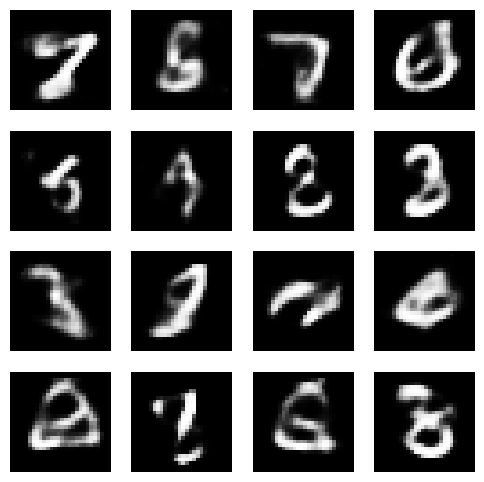

In [ ]:
######################
## IMAGE GENERATION ##
######################
# Place the model into evaluation mode and no not save the gradients.
model.eval()
with torch.no_grad():
    # Generate 16 random samples from the latent space by sampling from a standard 
    # normal distribution and then decode those samples to get the generated images.
    # 16 because we are plotting a 4x4 grid of images.
    z = torch.randn(16, latent_dim).to(device)
    # Decode the random samples to get the generated images. Note that the output of the 
    # decoder is a batch of 16 images of shape (16, 784) which we then reshape to be 
    # (16, 1, 28, 28) for plotting.
    samples = model.decode(z).cpu()
    samples = samples.view(16, 1, 28, 28)

# Plotting.
fig, axes = plt.subplots(4, 4, figsize=(6,6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(samples[i][0], cmap='gray')
    ax.axis('off')
plt.show()